In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

def print_mse_and_ssim(original_image, ruined_image):
    mse = mean_squared_error(original_image, ruined_image)
    (ssim, diff) = structural_similarity(original_image, ruined_image, full=True)
    print(f"mse = {mse}, ssim = {ssim}")

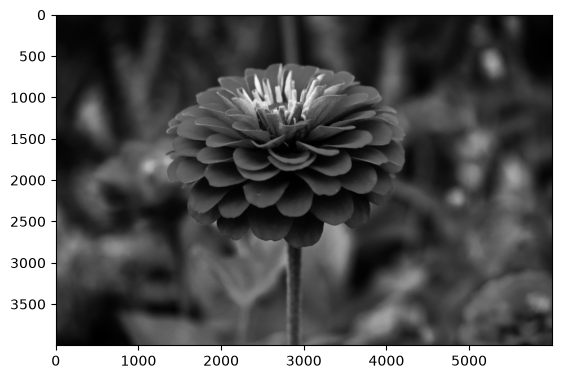

In [2]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
plt.imshow(image_gray, cmap="gray")

### 1. Зашумить изображение при помощи шума гаусса, постоянного шума.

#### Шум Гаусса:

mse = 10216.572864208334, ssim = 0.011603501872918934


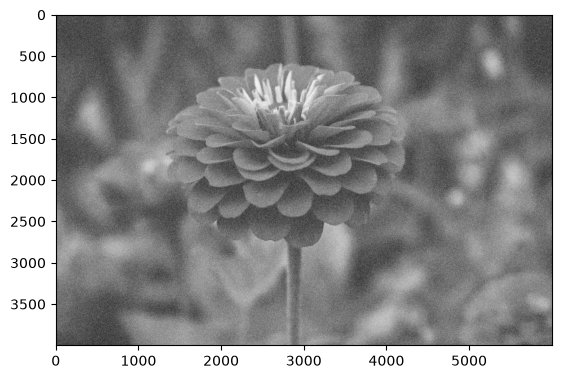

In [3]:
mean = 0
stddev = 200
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

# plt.imshow(noise_gauss, cmap="gray")

image_gauss = cv2.add(image_gray, noise_gauss)
plt.imshow(image_gauss, cmap="gray")

print_mse_and_ssim(image_gray, image_gauss)

##### Шум соль-перец:

mse = 2151.183697541667, ssim = 0.08784654522434288


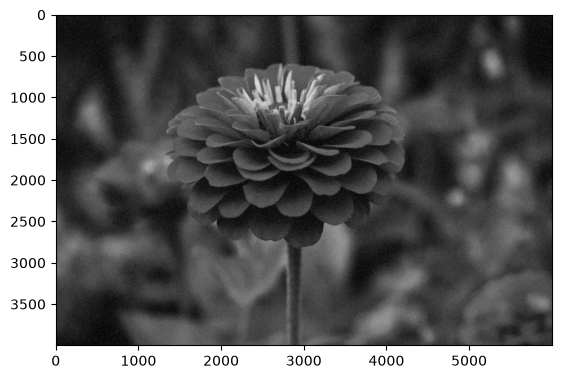

In [4]:
noise_saltpepper = np.random.randint(0, 21, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise_saltpepper == 0)
ones_pixel = np.where(noise_saltpepper == 20)

# bg_image = np.ones(image_gray.shape, np.uint8) * 128
# bg_image[zeros_pixel] = 0
# bg_image[ones_pixel] = 255
# plt.imshow(bg_image, cmap="gray")

image_saltpepper = copy.deepcopy(image_gray)
image_saltpepper[zeros_pixel] = 0
image_saltpepper[ones_pixel] = 255
plt.imshow(image_saltpepper, cmap="gray")

print_mse_and_ssim(image_gray, image_saltpepper)

### 2. Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

#### Медианный фильтр:

mse = 173.92960345833333, ssim = 0.7971046290667008


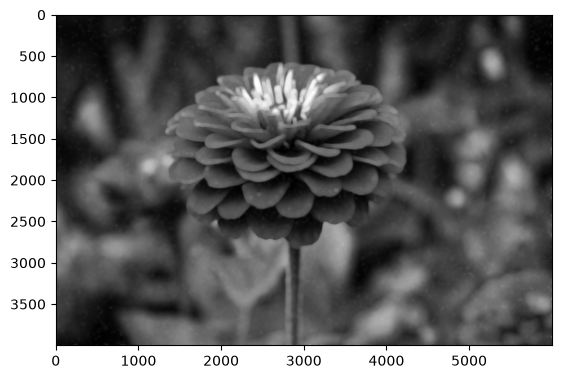

In [5]:
ksize = 41
image_gauss_median = cv2.medianBlur(image_gauss, ksize) #больше число - больше размытие
plt.imshow(image_gauss_median, cmap="gray")
print_mse_and_ssim(image_gray, image_gauss_median)

mse = 19.64595875, ssim = 0.8460965203991377


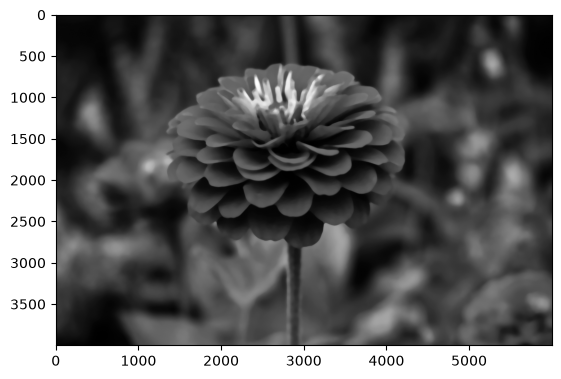

In [6]:
ksize = 41
image_saltpepper_median = cv2.medianBlur(image_saltpepper, ksize) #больше число - больше размытие
plt.imshow(image_saltpepper_median, cmap="gray")
print_mse_and_ssim(image_gray, image_saltpepper_median)

#### Фильтр Гаусса:

mse = 3954.335423708333, ssim = 0.5566850321687116


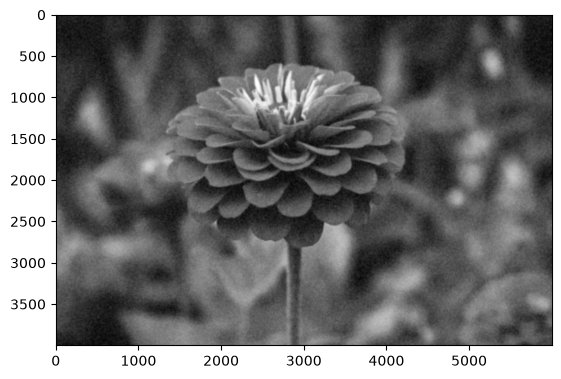

In [7]:
ksize = 41
image_gauss_gauss = cv2.GaussianBlur(image_gauss,(ksize,ksize),0)
plt.imshow(image_gauss_gauss, cmap="gray")
print_mse_and_ssim(image_gray, image_gauss_gauss)

mse = 78.68312220833333, ssim = 0.7946162949698272


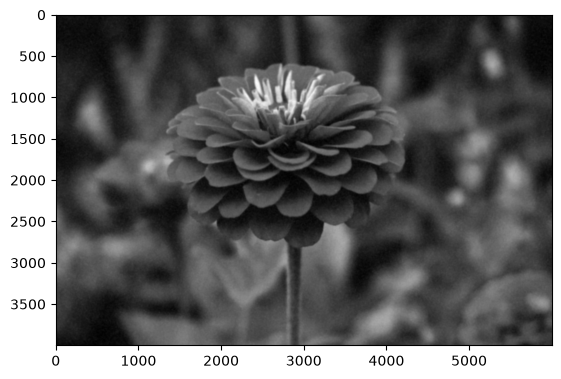

In [8]:
ksize = 41
image_saltpepper_gauss = cv2.GaussianBlur(image_saltpepper,(ksize,ksize),0)
plt.imshow(image_saltpepper_gauss, cmap="gray")
print_mse_and_ssim(image_gray, image_saltpepper_gauss)

#### Билатеральный фильтр:

mse = 6739.542200208333, ssim = 0.025467215290254152


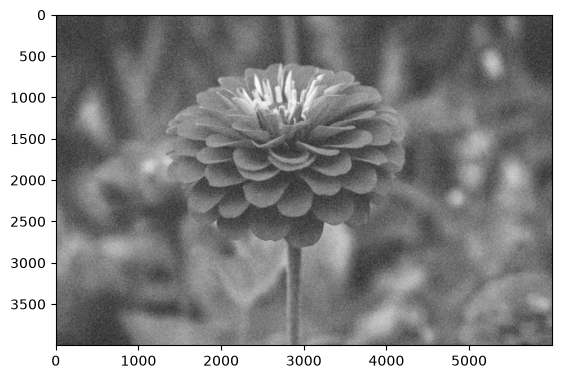

In [9]:
diam = 15
sigmaColor = 75
sigmaSpace = 25
image_gauss_bilat = cv2.bilateralFilter(image_gauss,diam,sigmaColor,sigmaSpace)
plt.imshow(image_gauss_bilat, cmap="gray")
print_mse_and_ssim(image_gray, image_gauss_bilat)

mse = 73.43215591666667, ssim = 0.6601041020501082


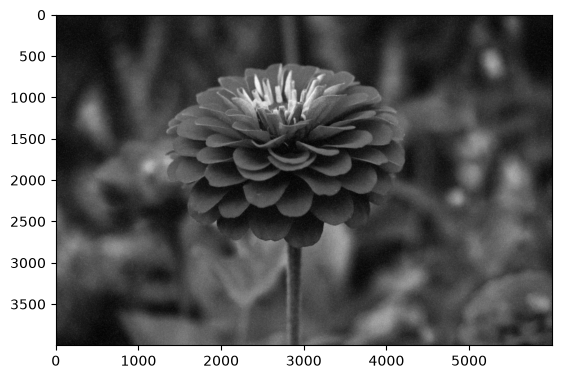

In [10]:
diam = 9
sigmaColor = 255
sigmaSpace = 75
image_saltpepper_bilat = cv2.bilateralFilter(image_saltpepper,diam,sigmaColor,sigmaSpace)
plt.imshow(image_saltpepper_bilat, cmap="gray")
print_mse_and_ssim(image_gray, image_saltpepper_bilat)

#### Фильтр нелокальных средних:

mse = 3849.2932305, ssim = 0.38456617279590827


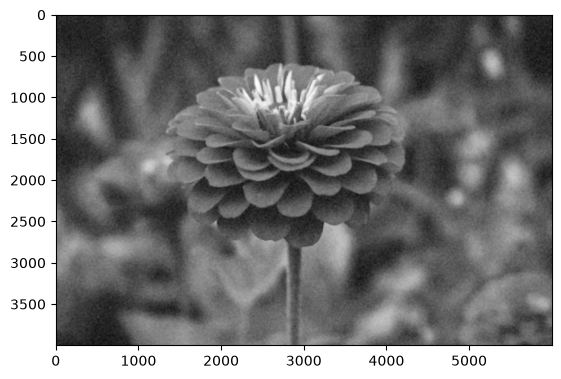

In [11]:
blurpower = 70
image_gauss_nlm = cv2.fastNlMeansDenoising(image_gauss, h = blurpower)
plt.imshow(image_gauss_nlm, cmap="gray")
print_mse_and_ssim(image_gray, image_gauss_nlm)

mse = 60.57901679166667, ssim = 0.7894003188412473


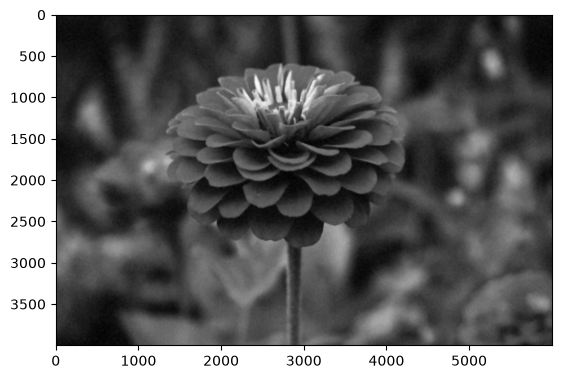

In [12]:
blurpower = 70
image_saltpepper_nlm = cv2.fastNlMeansDenoising(image_saltpepper, h = blurpower)
plt.imshow(image_saltpepper_nlm, cmap="gray")
print_mse_and_ssim(image_gray, image_saltpepper_nlm)

### 3. Выяснить, какой фильтр показал лучший результат фильтрации шума.

## Вывод:

##### Лучший результат при работе с шумом Гаусса показал медианный фильтр;

In [13]:
print_mse_and_ssim(image_gray, image_gauss_median)

mse = 173.92960345833333, ssim = 0.7971046290667008


##### Лучший результат при работе с шумом соль-перец также показал медианный фильтр.

In [14]:
print_mse_and_ssim(image_gray, image_saltpepper_median)

mse = 19.64595875, ssim = 0.8460965203991377
